In [1]:
import pandas as pd, numpy as np
from scipy.spatial.distance import squareform, pdist, cdist
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path, connected_components
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, gaussian_kde
from sklearn.decomposition import PCA
import dcor
import itertools
import joblib
import plot_style as ps

In [2]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "degrees": q, "w":w, "eps": eps, "alpha": alpha}

def reconstruct_path(pred, start, end):
    path = [end]; current = end
    while current != start:
        current = pred[start, current]
        if current == -9999: return None
        path.append(current)
    return path[::-1]

def graph_degree_density(Psi, h):
    Dsq = squareform(pdist(Psi)**2)
    rho = np.exp(-Dsq/h).sum(1)
    scale = rho.mean(); rho /= scale
    rho = np.maximum(rho, 1e-6)
    return rho, -np.log(rho), scale

def density_and_bandwidth(Psi, multiplier=0.1):
    N = Psi.shape[0]
    median_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
    h = multiplier * median_Dsq
    return h, median_Dsq, graph_degree_density(Psi, h)

def density_aware_cost(A_dist_sym, V, beta):
    rows, cols = A_dist_sym.nonzero()
    base = np.asarray(A_dist_sym[rows, cols]).ravel()
    costs = base*np.exp(beta*(V[rows]+V[cols])/2)
    return csr_matrix((costs, (rows, cols)), shape=A_dist_sym.shape)

def graph_path(A_dist_sym, beta, V, start, end):
    A = density_aware_cost(A_dist_sym, V, beta)
    _, pred = shortest_path(A, directed=False, return_predecessors=True)
    return reconstruct_path(pred, start, end)

def latent_density_at_points(gamma, Psi, h, scale):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query /= scale
    rho_query_floor = np.maximum(rho_query, 1e-6)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query


In [3]:
K_GRAPH = 15
BETA = 1.5
N_DIFFUSION_COORDS = 3
EPS_DIFFUSION = 3
N_LINEAR_GRID = 40
M_LIFT = 22


df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
dates = df.index; variables = df.columns[:-1]
Z = df.to_numpy()[:, :-1]; N = Z.shape[0]

obs_df = pd.read_parquet("./datasets/observed_df.parquet").loc[dates]
Z_real = obs_df[variables].to_numpy()

diff = diffusion_map(Z, EPS_DIFFUSION, k=N_DIFFUSION_COORDS)
Psi = diff["Psi"]

h_dens, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi)

endpoint_pairs = {"2006 benign -> 2008 GFC": ("2006-03-01", "2008-10-01"), "2019 benign -> 2020 COVID": ("2019-07-01", "2020-04-01"), 
                  "2019 benign -> 2021 Fiscal Tightening": ("2019-04-01", "2022-04-01"), "1977 benign -> 1982 Recession Trough": ("1977-01-01", "1982-07-01")}
pairs = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}

A_dist = kneighbors_graph(Psi, n_neighbors=K_GRAPH, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

# Stretch Goals
We have already completed (i), (ii), (iv), and (v) in Phase 8, 5, 7, and 8 resp.

#### Nystrom lift (from Initial tasks, phase 4)

In [4]:
def nystrom_lift(y_new, x_ambient, store, k=2):
    eps, alpha = store["eps"], store["alpha"]
    lam = store["w"][1:k+1]; phi = store["phi"][:, 1:k+1]
    y_new = np.atleast_2d(y_new)
    wn = np.exp(-cdist(y_new, x_ambient)**2/eps)        # [C8]
    qn = wn.sum(1, keepdims=True)
    wa = wn/((qn**alpha)*(store["degrees"][None, :]**alpha))
    pn = wa/wa.sum(1, keepdims=True)
    phi_new = (pn @ phi)/lam
    return (lam*phi_new).squeeze()

I choose a hypothetical stress pair made up from a linear combination of our current stress points

In [5]:
def generate_affine_candidates(coord_idx, Z, diff, weight_min=-5.0, weight_max=5.0, weight_step=0.5, nystrom_k=3, max_abs_quantile=4.5, max_dnn=None):
    coord_idx = np.asarray(coord_idx); anchors = Z[coord_idx]
    grid = np.arange(weight_min, weight_max + weight_step / 2, weight_step)

    first_weights = np.array(list(itertools.product(grid, repeat=len(coord_idx) - 1)), dtype=float)

    final_weight = 1.0 - first_weights.sum(axis=1, keepdims=True)
    weights = np.hstack([first_weights, final_weight])

    valid = ((weights[:, -1] >= weight_min) & (weights[:, -1] <= weight_max))
    weights = weights[valid]
    Z_candidates = weights @ anchors

    valid = np.all(np.abs(Z_candidates) <= max_abs_quantile, axis=1)
    weights = weights[valid]; Z_candidates = Z_candidates[valid]

    nn = NearestNeighbors(n_neighbors=1).fit(Z)
    candidate_dNN, _ = nn.kneighbors(Z_candidates)
    candidate_dNN = candidate_dNN.ravel()

    if max_dnn is not None:
        valid = candidate_dNN <= max_dnn
        weights = weights[valid]
        Z_candidates = Z_candidates[valid]
        candidate_dNN = candidate_dNN[valid]

    Psi_candidates = np.vstack([np.asarray(nystrom_lift(z, Z, diff, k=nystrom_k)).ravel() for z in Z_candidates])

    return {"weights": weights, "Z_quantile": Z_candidates, "Psi": Psi_candidates, "dNN": candidate_dNN}

In [6]:
coord_idx = [pairs["2006 benign -> 2008 GFC"][1], pairs["2019 benign -> 2021 Fiscal Tightening"][1], pairs["2006 benign -> 2008 GFC"][0], pairs["2019 benign -> 2020 COVID"][1]]

nn = NearestNeighbors(n_neighbors=2).fit(Z)
historical_dNN, _ = nn.kneighbors(Z)
historical_dNN = historical_dNN[:, 1]

historical_median = np.median(historical_dNN)
historical_95 = np.quantile(historical_dNN, 0.95)

candidate_pool = generate_affine_candidates(coord_idx=coord_idx, Z=Z, diff=diff, weight_min=-5, 
                                            weight_max=5, weight_step=0.5, nystrom_k=3, max_abs_quantile=4.5, max_dnn=2 * historical_95)

print("Number of valid candidates:", len(candidate_pool["weights"]))

Number of valid candidates: 150


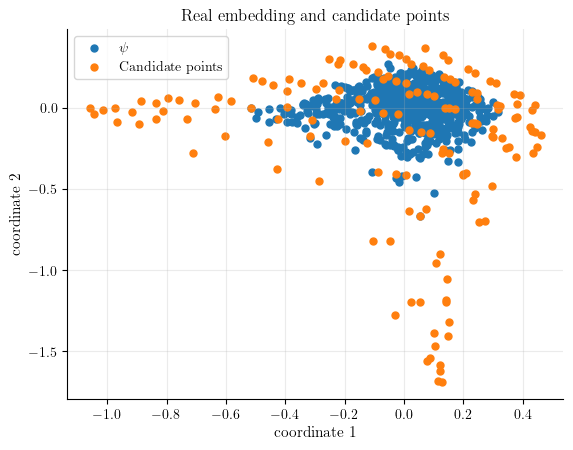

In [7]:
plt.scatter(Psi[:, 0], Psi[:, 1], label=r"$\psi$")
plt.scatter(candidate_pool["Psi"][:, 0], candidate_pool["Psi"][:, 1], label="Candidate points")
plt.title("Real embedding and candidate points")
plt.xlabel(r"coordinate 1"); plt.ylabel(r"coordinate 2")
plt.legend()
plt.show()

In [8]:
def select_candidate_near_target(candidate_pool, target):
    Psi_candidates = candidate_pool["Psi"]; target = np.asarray(target)
    return np.argmin(np.linalg.norm(Psi_candidates[:, :2] - target, axis=1))

In [9]:
benign_idx = select_candidate_near_target(candidate_pool, [-0.1, 0.25])
stress_idx = select_candidate_near_target(candidate_pool, [0.2, -0.75])

benign_weights = candidate_pool["weights"][benign_idx]
stress_weights = candidate_pool["weights"][stress_idx]

z_benign = candidate_pool["Psi"][benign_idx]
z_stress = candidate_pool["Psi"][stress_idx]

Psi_extended = np.vstack([Psi, z_benign, z_stress])

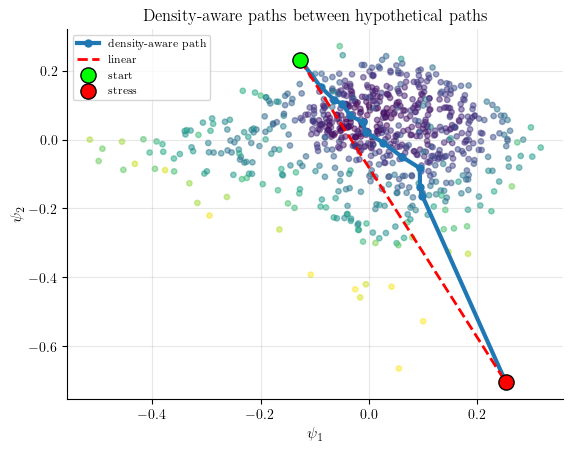

In [10]:
h_dens, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi_extended)
A_dist = kneighbors_graph(Psi_extended, n_neighbors=K_GRAPH, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

idx_path = graph_path(A_dist_sym, beta=BETA, V=V, start=743, end=744)
P = Psi_extended[idx_path]

plt.scatter(Psi_extended[:,0], Psi_extended[:,1], c=V, s=15, cmap="viridis", alpha=.5)
plt.plot(P[:,0], P[:,1], marker="o", ms=5, label="density-aware path", linewidth=3)

lin = np.linspace(Psi_extended[-2], Psi_extended[-1], 10)
plt.plot(lin[:,0], lin[:,1], "r--", lw=2, label="linear")

plt.scatter(*Psi_extended[-2,:2], c="lime", s=120, ec="k", zorder=5, label="start")
plt.scatter(*Psi_extended[-1,:2], c="red", s=120, ec="k", zorder=5, label="stress")

plt.title("Density-aware paths between hypothetical paths"); plt.xlabel(r"$\psi_1$")
plt.ylabel(r"$\psi_2$"); plt.legend(fontsize=8)
plt.grid(alpha=.3)

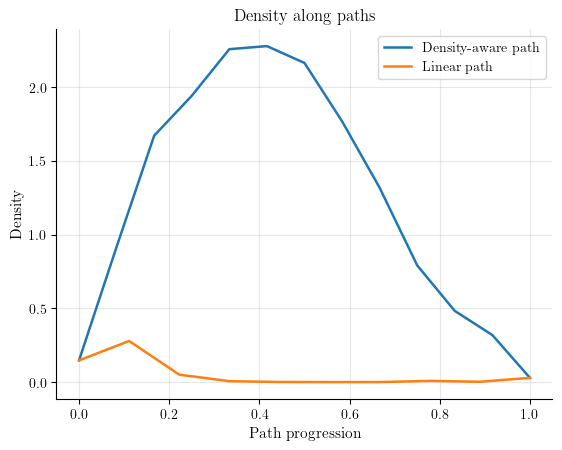

In [11]:
da_density = rho[idx_path]
lin_density, _ = latent_density_at_points(lin, Psi_extended, h_dens, scale)


plt.plot(np.linspace(0, 1, len(da_density)), da_density, label="Density-aware path")
plt.plot(np.linspace(0, 1, len(lin_density)), lin_density, label="Linear path")
plt.title("Density along paths"); plt.xlabel("Path progression")
plt.ylabel("Density"); plt.grid(alpha=0.3); plt.legend()
plt.show()


I chose this pair of endpoint to exagurate the effect of the density-aware path. Although the plot above is slighly too much in a way. The graph path jumps between nodes it can take a massive jump over the sparse region, whereas the evenly spaced linear path is forced to travel through the sparse region. Plotting these side by side as with the path progression in the x-axis is slighly misrepresenting things. The graph path spent most of its time in the highly dense region and took one massive jump to the stress state. At first glance, the plot could suggest to some readers that for each point on the linear path, the graph path found a much more dense point. This is not the case.

If this needs amending, one could orthogonally project the graph path points onto the linear path and find the densities of those points, which would then give the plot a more natural meaning. At the same time, this does also show how poorly linearly interpolation does going between points, because without the diffusion map, how would the linear path know where to take its steps? It would most likely return evenly spaced points, which is what we have plotted.